<a href="https://colab.research.google.com/github/atikhasan007/DeepLearning/blob/main/pytorch/14_Convolutional_Neural_Network_(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

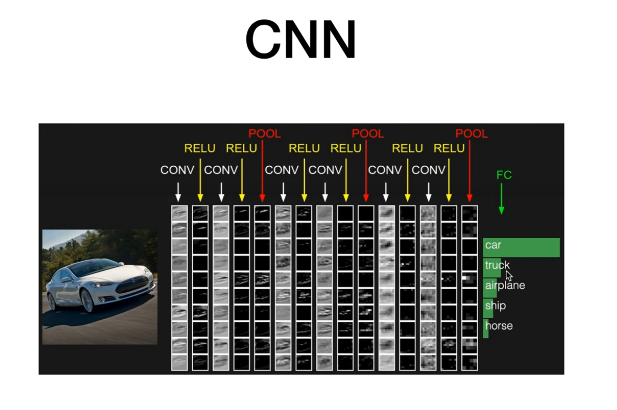

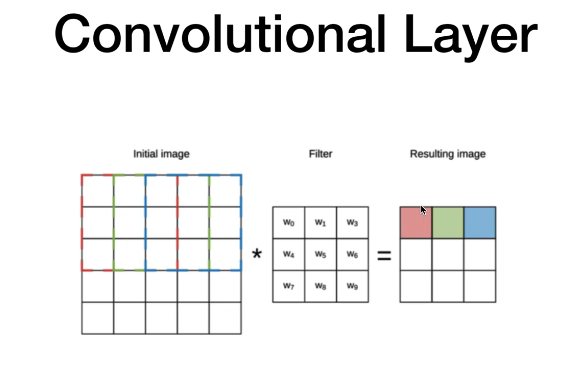

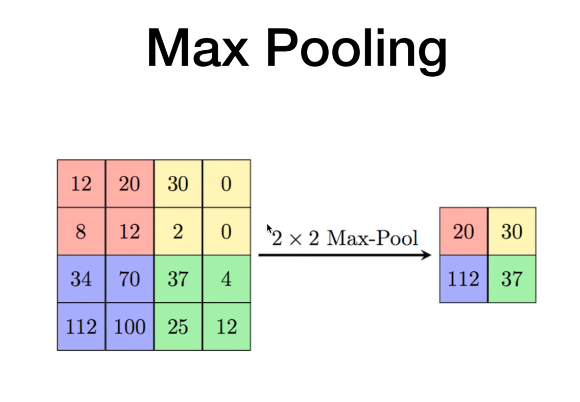

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms # এটি PIL image বা NumPy array কে PyTorch Tensor এ convert করে।
import matplotlib.pyplot as plt
import numpy as np

In [22]:
# device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [23]:
# Hyper - parameters
num_epochs = 4
batch_size = 4
learning_rate = 0.001


In [24]:
# Dataset has PILImages of range [0,1]
# we transform them to Tensors of normalized range [-1, 1]
# image shape -> height x width x channel
# tensor shape -> channel x height x width
# normalize law -> new value = (old_value - mean )/ std
# channel rgb
# Pixel value 0-255 থেকে 0-1 এ আনা
# এরপর Normalize করে -1 থেকে 1 range এ নেওয়া

transform = transforms.Compose( # Compose() দিয়ে একাধিক transform একসাথে করা হয়েছে।
    [transforms.ToTensor(), # এটি image কে PyTorch Tensor এ convert করে।
     transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))] # এটি image এর pixel value normalize করে।

)


train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform )




In [25]:
# dataset loader
# dataset কে batch আকারে model-এ পাঠানোর জন্য ব্যবহার করা হয়।
# benifit -> কম RAM/GPU memory ব্যবহার করে
#         -> Training দ্রুত হয়
#         -> Gradient update নিয়মিত হয়

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True # Training data-কে প্রতি epoch-এর শুরুতে এলোমেলো করে।
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [26]:
classes = (
    'plane',
    'car',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck')

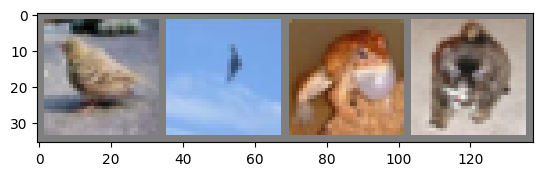

torch.Size([4, 3, 32, 32])


In [27]:
from torchvision.datasets.vision import data
def imshow(img):
  img = img / 2 + 0.5  # unnormalize
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.show()

# get some random training image
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show image
imshow(torchvision.utils.make_grid(images))
conv1 = nn.Conv2d(3,6,5)
pool = nn.MaxPool2d(2,2)
conv2 = nn.Conv2d(6,16,5)
print(images.shape)




In [28]:
x = conv1(images)
print(x.shape)

torch.Size([4, 6, 28, 28])


In [29]:
x = pool(x)
print(x.shape)

torch.Size([4, 6, 14, 14])


In [30]:
x = conv2(x)
print(x.shape)



torch.Size([4, 16, 10, 10])


In [31]:
x = pool(x)
print(x.shape)

torch.Size([4, 16, 5, 5])


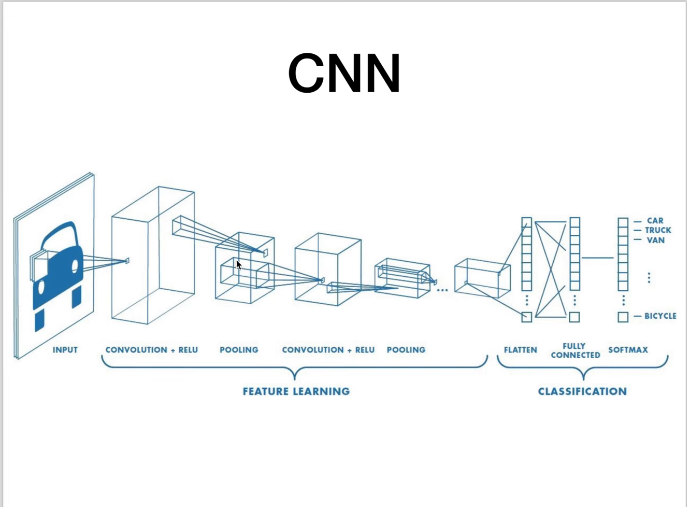

In [34]:
# super().__init__() → PyTorch internal setup চালু করে
import torch
import torch.nn as nn
import torch.nn.functional as F

# implemet conv net
class ConvNet(nn.Module):
  def __init__(self): #
    super().__init__() # Call the constructor of the parent class (nn.Module)
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
    self.fc1 = nn.Linear(in_features=16*5*5, out_features=120)
    self.fc2 = nn.Linear(in_features=120, out_features=84)
    self.fc3 = nn.Linear(in_features=84, out_features=10)

 # data flow define করা হয়
  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = x.view(-1, 16*5*5)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)

    return x

In [35]:
# create model
model = ConvNet().to(device)

In [36]:
# loss and optimizer
# SGD -> The model is update using a single data point in each iteration
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


In [37]:
# n_total_steps = len(train_loader)
# n_total_steps

# total train image = 50,000
# batch_size = 4
# total steps = total_tarin_image / batch_size

In [38]:
# training loop
# len(train_loader) দিয়ে এক epoch-এ মোট কতগুলো batch আছে তা পাওয়া যায়।
# Model কতবার পুরো training dataset দেখবে সেটি নির্ধারণ করে। epoch loop
# i is batch number
# to(device) # device যদি GPU হয়, image GPU memory-তে যাবে।
# GPU না থাকলে CPU-তে থাকবে।

n_total_steps = len(train_loader) # 12500

for epoch in range(num_epochs): # epoch is 4
    for i, (images, labels) in enumerate(train_loader):
        # origin shape: [4,3,32,32] = 4, 3, 1024
        # input_layer: 3 input channels, 6 output channels, 5 kernel size

        images = images.to(device)
        labels = labels.to(device)


        # forward pass
        outputs = model(images)
        loss = criterion(outputs, labels) # Prediction এবং আসল label-এর পার্থক্য বের করে।

        # Backward and optimize
        optimizer.zero_grad() # Previous Gradient Clear
        loss.backward() # loss -> backward pass -> gradient calculate
        optimizer.step() # old weight -> gradient -> new better weight Wnew​=Wold​−learning_rate×gradient


        if (i+1) % 2000 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

print("Finished Training")

Epoch [1/4], Step [2000/12500], Loss: 2.2961
Epoch [1/4], Step [4000/12500], Loss: 2.3156
Epoch [1/4], Step [6000/12500], Loss: 2.2856
Epoch [1/4], Step [8000/12500], Loss: 2.2901
Epoch [1/4], Step [10000/12500], Loss: 2.2617
Epoch [1/4], Step [12000/12500], Loss: 2.1894
Epoch [2/4], Step [2000/12500], Loss: 1.8261
Epoch [2/4], Step [4000/12500], Loss: 2.5480
Epoch [2/4], Step [6000/12500], Loss: 1.6138
Epoch [2/4], Step [8000/12500], Loss: 2.0614
Epoch [2/4], Step [10000/12500], Loss: 1.7049
Epoch [2/4], Step [12000/12500], Loss: 1.5122
Epoch [3/4], Step [2000/12500], Loss: 1.4922
Epoch [3/4], Step [4000/12500], Loss: 1.7197
Epoch [3/4], Step [6000/12500], Loss: 1.7579
Epoch [3/4], Step [8000/12500], Loss: 1.0218
Epoch [3/4], Step [10000/12500], Loss: 1.5709
Epoch [3/4], Step [12000/12500], Loss: 1.4066
Epoch [4/4], Step [2000/12500], Loss: 1.9068
Epoch [4/4], Step [4000/12500], Loss: 1.9479
Epoch [4/4], Step [6000/12500], Loss: 1.6878
Epoch [4/4], Step [8000/12500], Loss: 2.1010
Epoc

In [39]:
# testing or evaluation loop
"""Gradient calculation বন্ধ করা
Testing এর সময় আমরা model-এর weight update করি না।
তাই gradient calculate করার দরকার নেই।
এতে memory কম লাগে এবং execution দ্রুত হয়।
"""
# training
# forward -> loss -> backward -> update weight

# testing
# forward -> prediction -> accuracy calculation



with torch.no_grad(): # Gradient calculation বন্ধ করা
  n_correct = 0 # এখানে মোট কতগুলো image সঠিকভাবে predict হয়েছে তা রাখা হবে।
  n_samples = 0 # মোট কতগুলো test image পরীক্ষা করা হয়েছে তা রাখা হবে।
  n_class_correct = [0 for i in range(10)]
  n_class_samples = [0 for i in range(10)]

# Test loader থেকে batch নেওয়া
# test dataset থেকে এক batch করে image এবং label নেওয়া হচ্ছে।
  for images, labels in test_loader:
    # Data কে device-এ পাঠানো
    images = images.to(device)
    labels = labels.to(device)
    outputs = model(images) # Forward pass

    # max returns (value, index)
    # Highest score-এর class বের করা
    # torch.max() দুটি জিনিস return করে: 1. value 2. index
    # _ দিয়ে max value ফেলে দেওয়া হয়েছে।
    _, predicted = torch.max(outputs, 1)
    n_samples += labels.size(0)
    n_correct += (predicted == labels).sum().item()

    # প্রতিটি class-এর accuracy বের করার জন্য loop
    for i in range(labels.size(0)):
      label = labels[i]
      pred = predicted[i]
      if (label == pred):
        n_class_correct[label] += 1
      n_class_samples[label] += 1

  acc = 100.0 * n_correct / n_samples
  print(f"Accuracy of the network: {acc} %")

  for i in range(10):
    acc = 100.0 * n_class_correct[i] / n_class_samples[i]
    print(f"Accuracy of {classes[i]}: {acc} %")


Accuracy of the network: 45.46 %
Accuracy of plane: 66.9 %
Accuracy of car: 60.4 %
Accuracy of bird: 33.0 %
Accuracy of cat: 31.2 %
Accuracy of deer: 28.7 %
Accuracy of dog: 32.7 %
Accuracy of frog: 43.4 %
Accuracy of horse: 58.0 %
Accuracy of ship: 39.3 %
Accuracy of truck: 61.0 %
